### Imports

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

plt.style.use("default")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


### Load All Datasets

In [3]:
import pandas as pd

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav_history = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category_inflow = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

scheme_perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


### Dataset Overview

In [4]:
datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "aum": aum,
    "sip": sip,
    "category_inflow": category_inflow,
    "folio": folio,
    "scheme_perf": scheme_perf,
    "transactions": transactions,
    "portfolio": portfolio,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("Shape:", df.shape)

fund_master
Shape: (40, 15)
nav_history
Shape: (46000, 3)
aum
Shape: (90, 5)
sip
Shape: (48, 6)
category_inflow
Shape: (144, 3)
folio
Shape: (21, 6)
scheme_perf
Shape: (40, 20)
transactions
Shape: (32778, 14)
portfolio
Shape: (322, 8)
benchmark
Shape: (8050, 3)


### Important Columns Check

In [5]:
for name, df in {
    "sip": sip,
    "category_inflow": category_inflow,
    "folio": folio,
    "portfolio": portfolio,
    "benchmark": benchmark
}.items():

    print("\n")
    print("=" * 60)
    print(name)
    print(df.columns.tolist())



sip
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


category_inflow
['month', 'category', 'net_inflow_crore']


folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


portfolio
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


benchmark
['date', 'index_name', 'close_value']


## CHarts

### NAV Trend Analysis

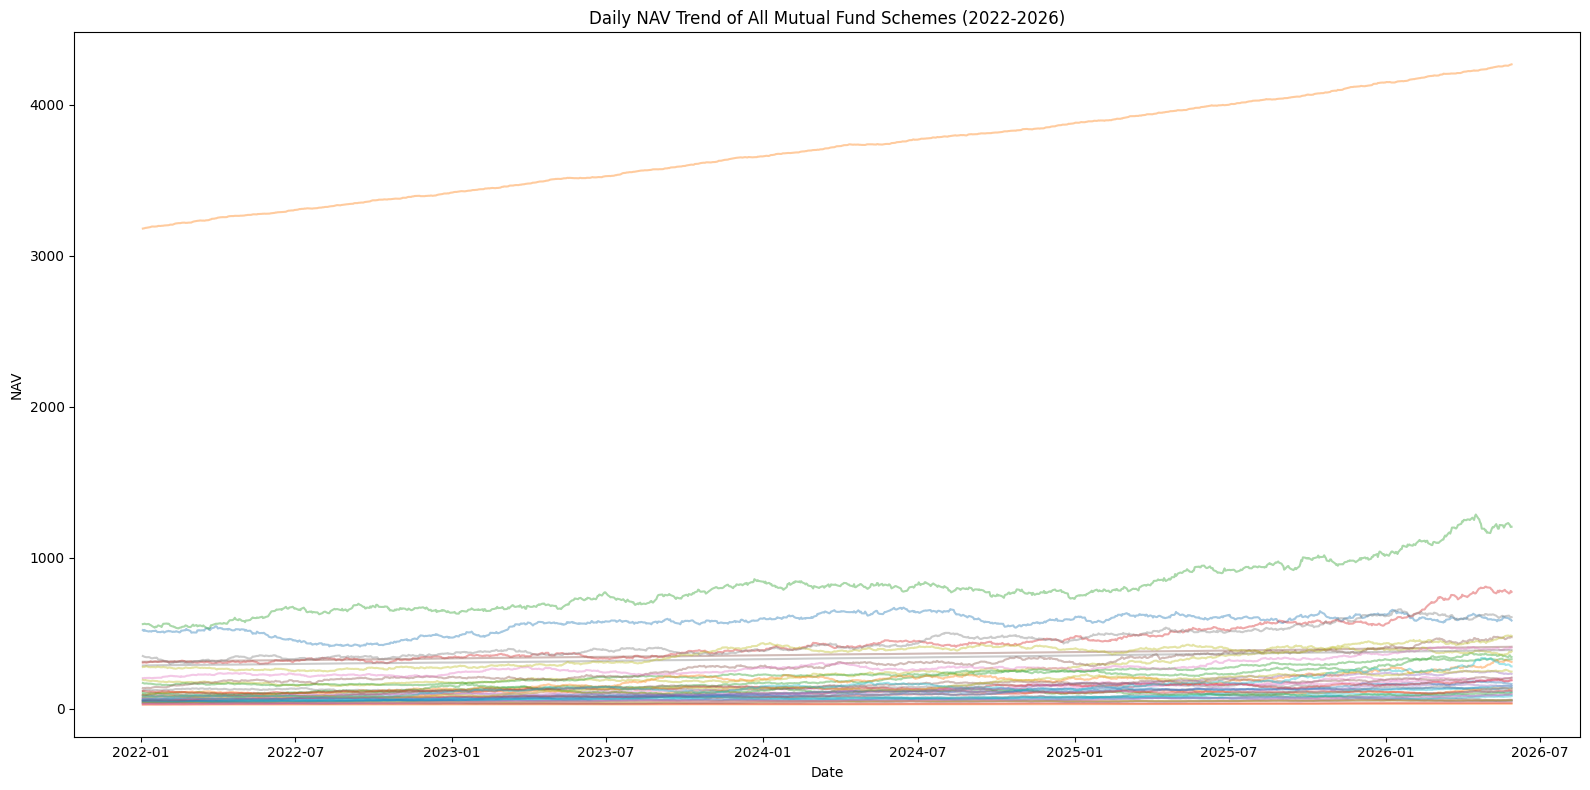

In [18]:
from pathlib import Path
import matplotlib.pyplot as plt

Path("../reports/charts").mkdir(
    parents=True,
    exist_ok=True
)

plt.figure(figsize=(16,8))

for scheme in nav_history["amfi_code"].unique():
    temp = nav_history[
        nav_history["amfi_code"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        alpha=0.4
    )

plt.title(
    "Daily NAV Trend of All Mutual Fund Schemes (2022-2026)"
)

plt.xlabel("Date")
plt.ylabel("NAV")

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight 1

Daily NAV trends show a steady upward movement across most schemes between 2022 and 2026, indicating long-term growth in the mutual fund market.

**Reference:** NAV Trend Analysis

### AUM Growth by Fund House

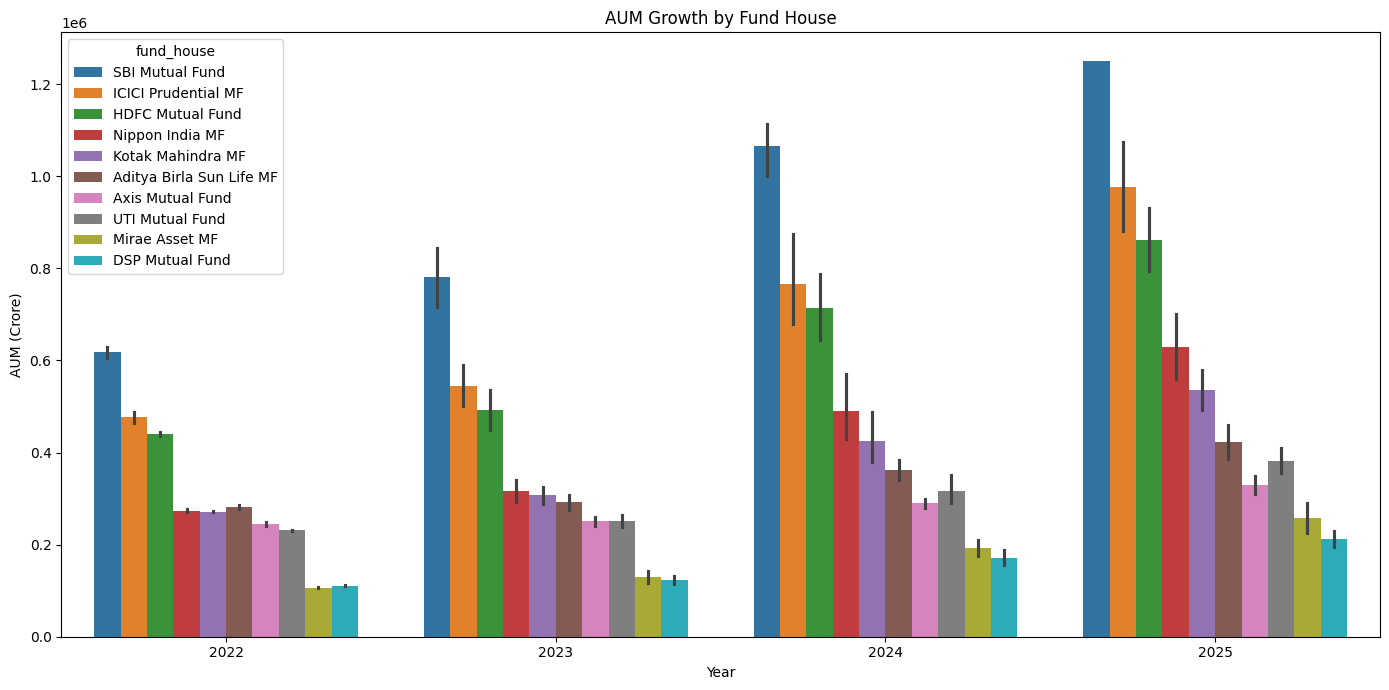

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

top_funds = (
    aum.groupby("fund_house")["aum_crore"]
    .max()
    .sort_values(ascending=False)
    .head(10)
    .index
)

aum_top = aum[aum["fund_house"].isin(top_funds)]

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_top,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.ylabel("AUM (Crore)")
plt.xlabel("Year")

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight 2

SBI Mutual Fund consistently maintained the highest AUM among all fund houses, demonstrating strong market leadership.

**Reference:** AUM Growth by Fund House

### SIP Inflow Trend

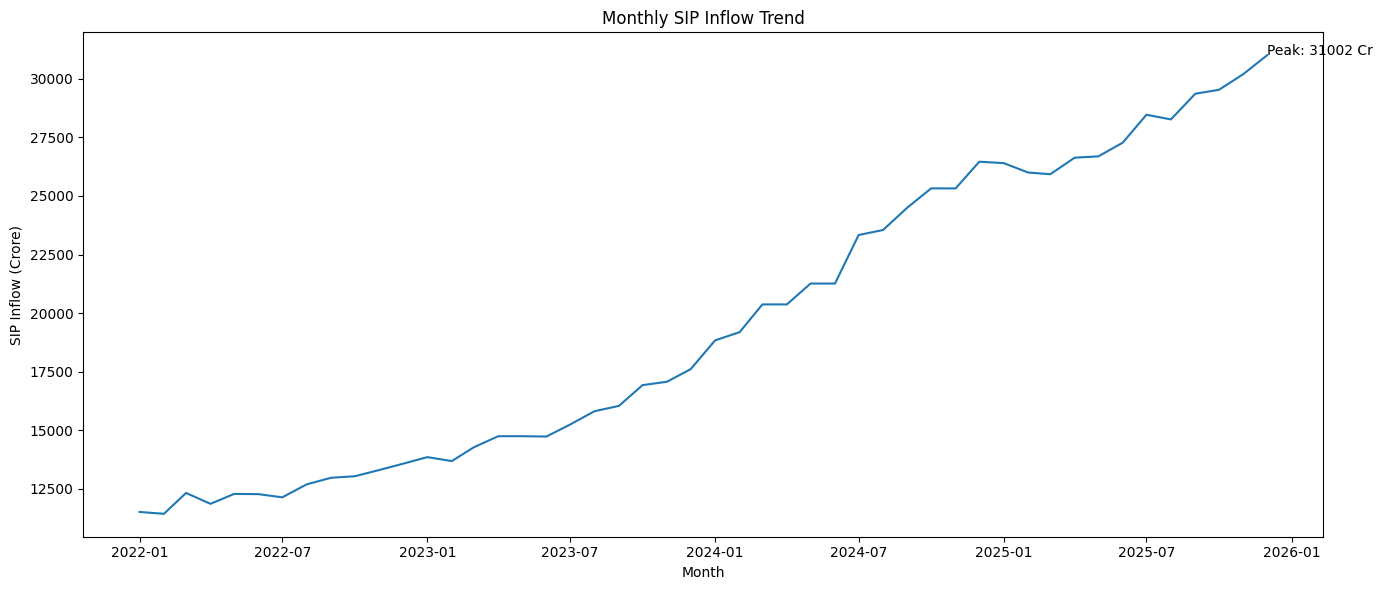

In [21]:
from pathlib import Path
import matplotlib.pyplot as plt

Path("../reports/charts").mkdir(
    parents=True,
    exist_ok=True
)

sip["month"] = pd.to_datetime(
    sip["month"]
)

plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

max_idx = sip["sip_inflow_crore"].idxmax()

plt.annotate(
    f"Peak: {sip.loc[max_idx,'sip_inflow_crore']:.0f} Cr",
    (
        sip.loc[max_idx,"month"],
        sip.loc[max_idx,"sip_inflow_crore"]
    )
)

plt.title("Monthly SIP Inflow Trend")

plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sip_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight 3

Monthly SIP inflows increased significantly over the study period, reflecting growing retail participation in mutual funds.

**Reference:** Monthly SIP Inflow Trend

### Category Inflow Heatmap

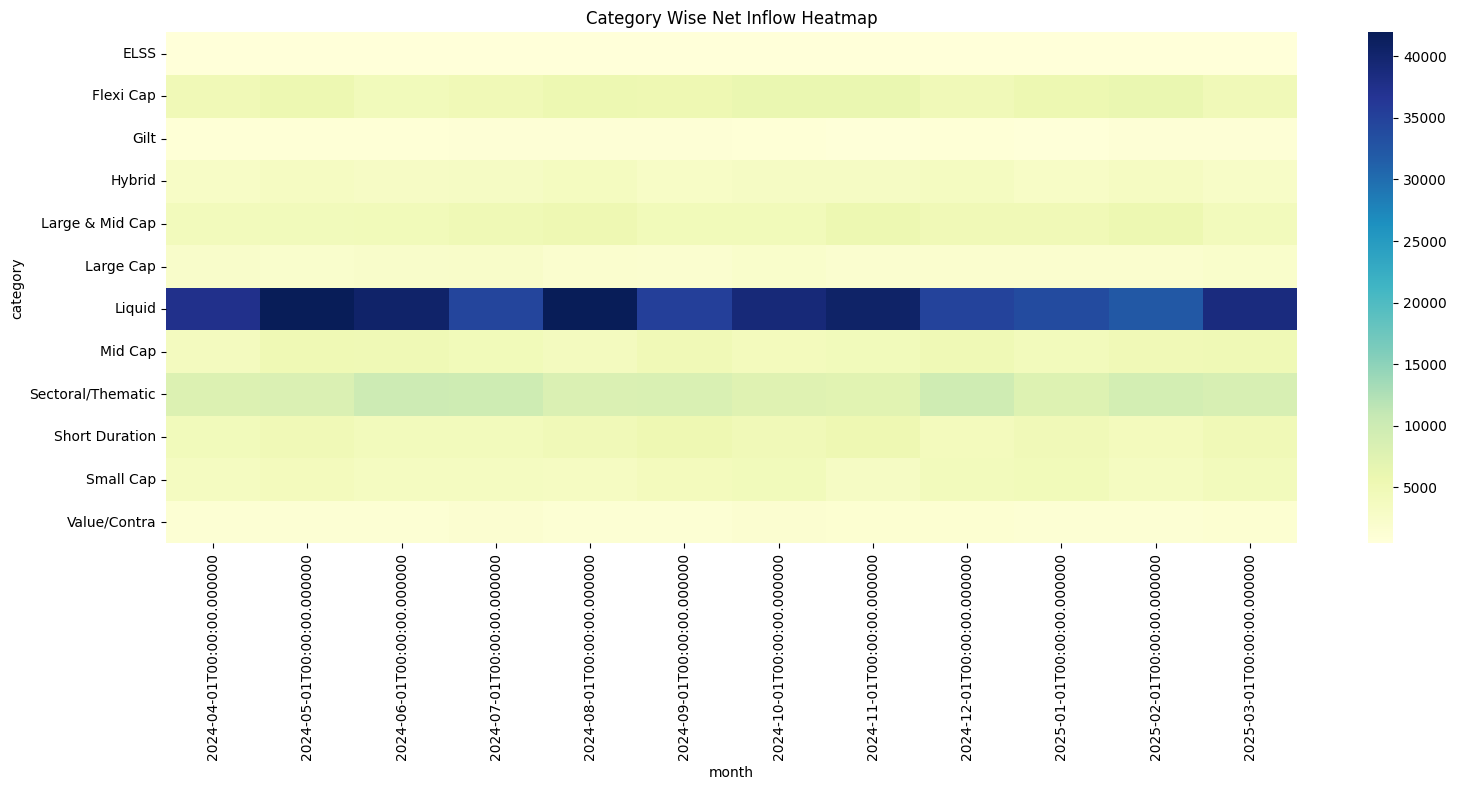

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

Path("../reports/charts").mkdir(
    parents=True,
    exist_ok=True
)

category_inflow["month"] = pd.to_datetime(
    category_inflow["month"]
)

heatmap_data = category_inflow.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Wise Net Inflow Heatmap")

plt.tight_layout()

plt.savefig(
    "../reports/charts/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight 4

Certain fund categories received substantially higher inflows than others, indicating investor preference concentration.

**Reference:** Category Inflow Heatmap

### Age Group Distribution Pie Chart

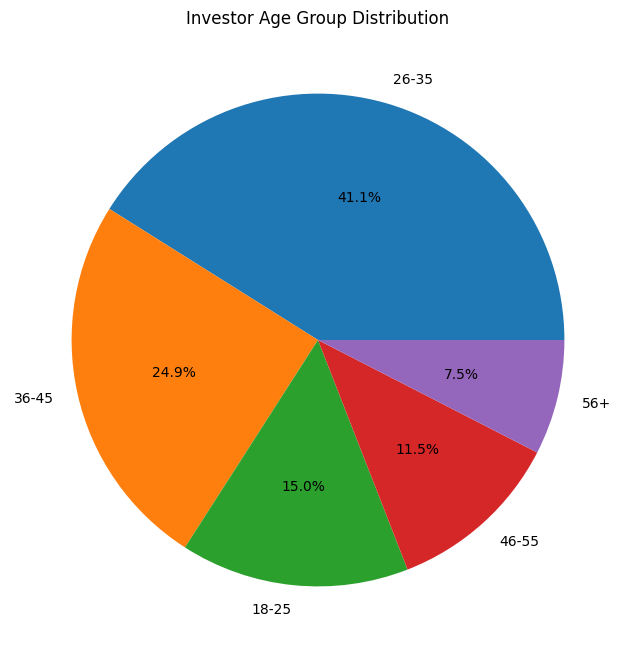

In [23]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.ylabel("")

plt.savefig(
    "../reports/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight 5

The 26–35 and 36–45 age groups contribute the largest share of mutual fund investments.

**Reference:** Age Group Distribution

### SIP Amount Box Plot by Age Group

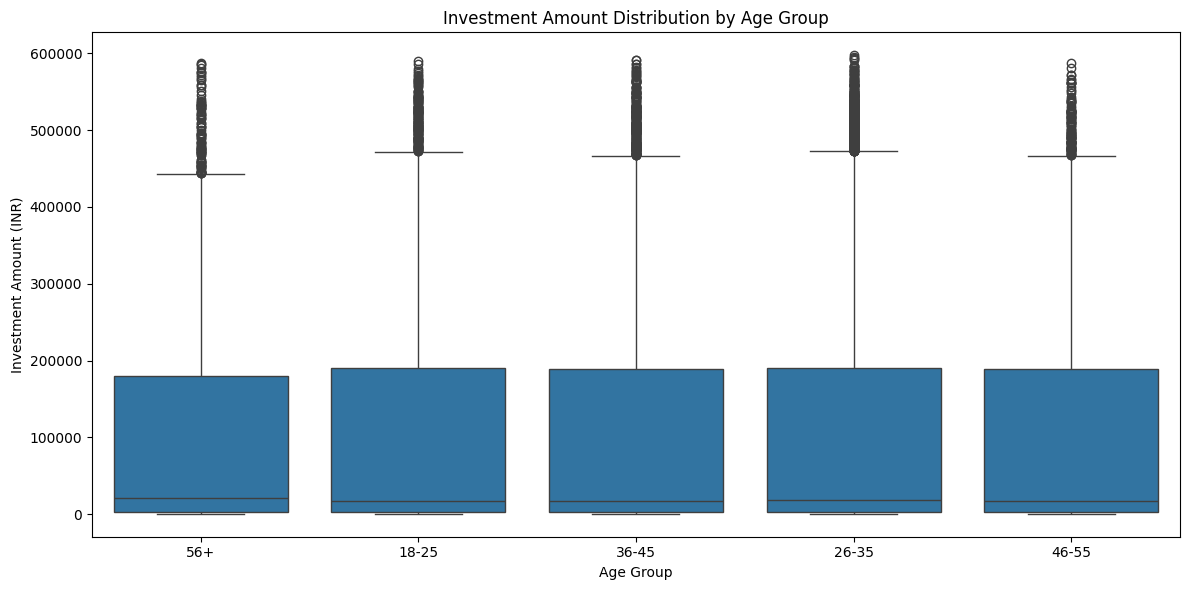

In [24]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")

plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sip_boxplot_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight 6

Investment amounts vary across age groups, with middle-aged investors generally making larger investments.

**Reference:** Investment Amount by Age Group

### Gender Split

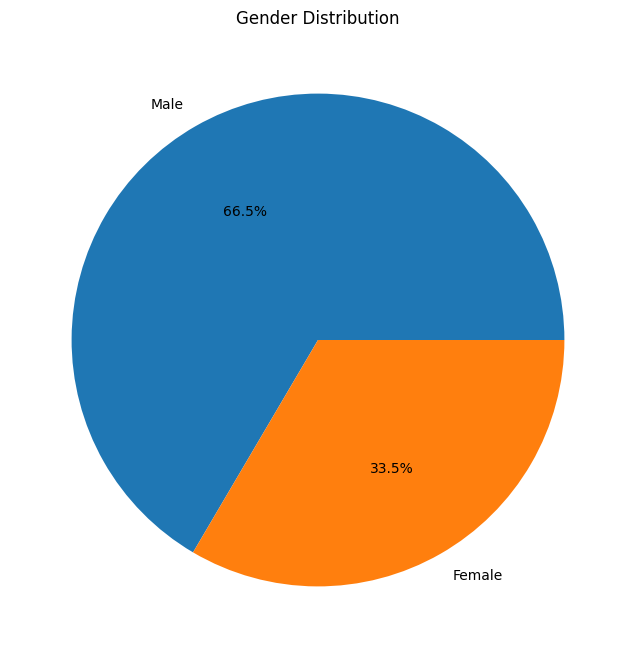

In [25]:
plt.figure(figsize=(8,8))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.savefig(
    "../reports/charts/gender_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight 7

Male investors account for a larger proportion of transactions compared to female investors.

**Reference:** Gender Split

### Geographic Distribution (State Wise SIP Amount)

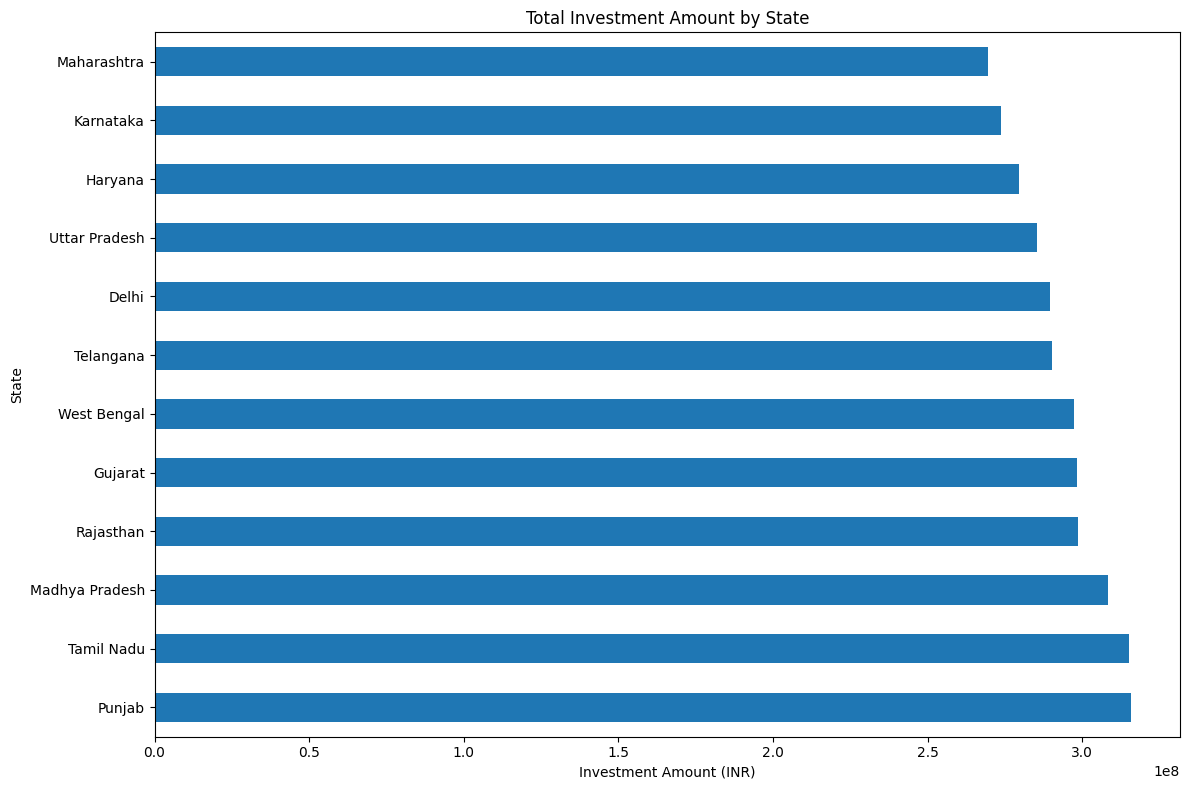

In [26]:
plt.figure(figsize=(12,8))

state_data = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_data.plot(
    kind="barh"
)

plt.title("Total Investment Amount by State")

plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/state_wise_investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight 8

Investment activity is concentrated in a limited number of states, suggesting regional differences in mutual fund adoption.

**Reference:** State-wise Investment Analysis

### T30 vs B30 Pie Chart

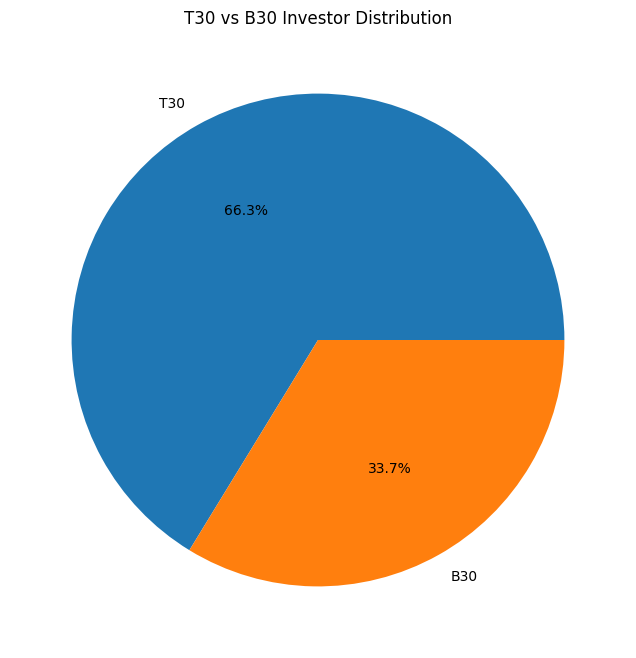

In [27]:
plt.figure(figsize=(8,8))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.ylabel("")

plt.savefig(
    "../reports/charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Folio Count Growth

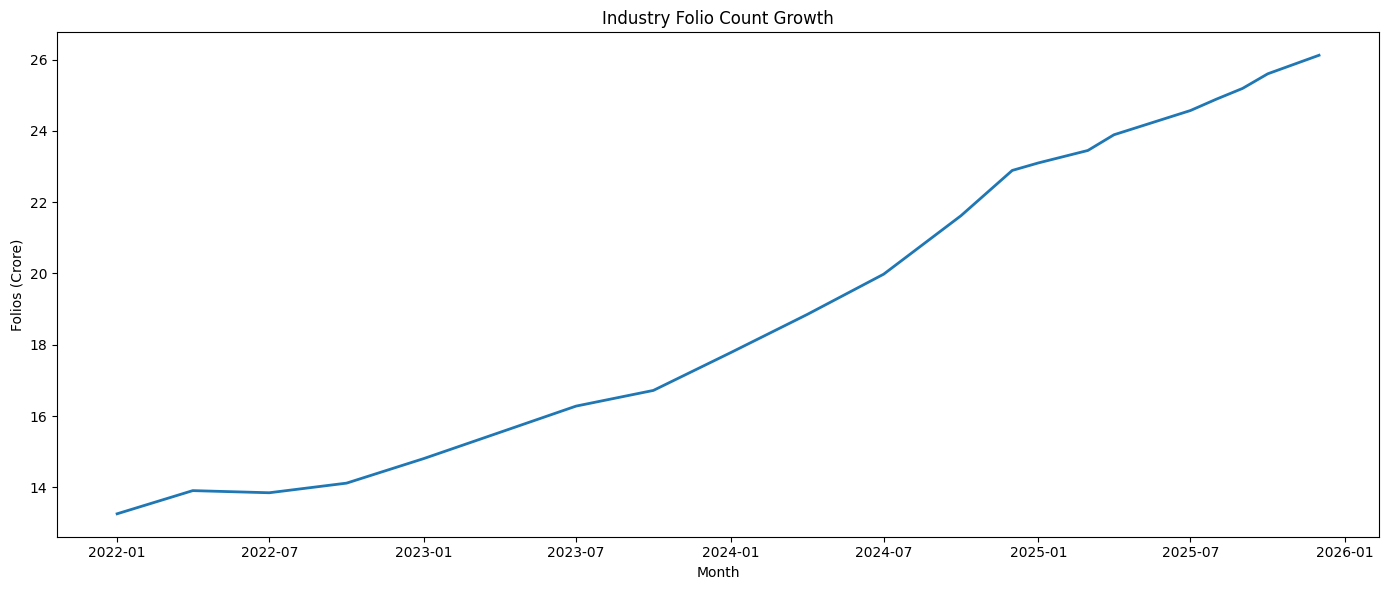

In [28]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    linewidth=2
)

plt.title("Industry Folio Count Growth")

plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight 9

Industry folio counts more than doubled during the analysis period, indicating strong growth in investor participation.

**Reference:** Folio Count Growth

### Equity vs Debt vs Hybrid Folios

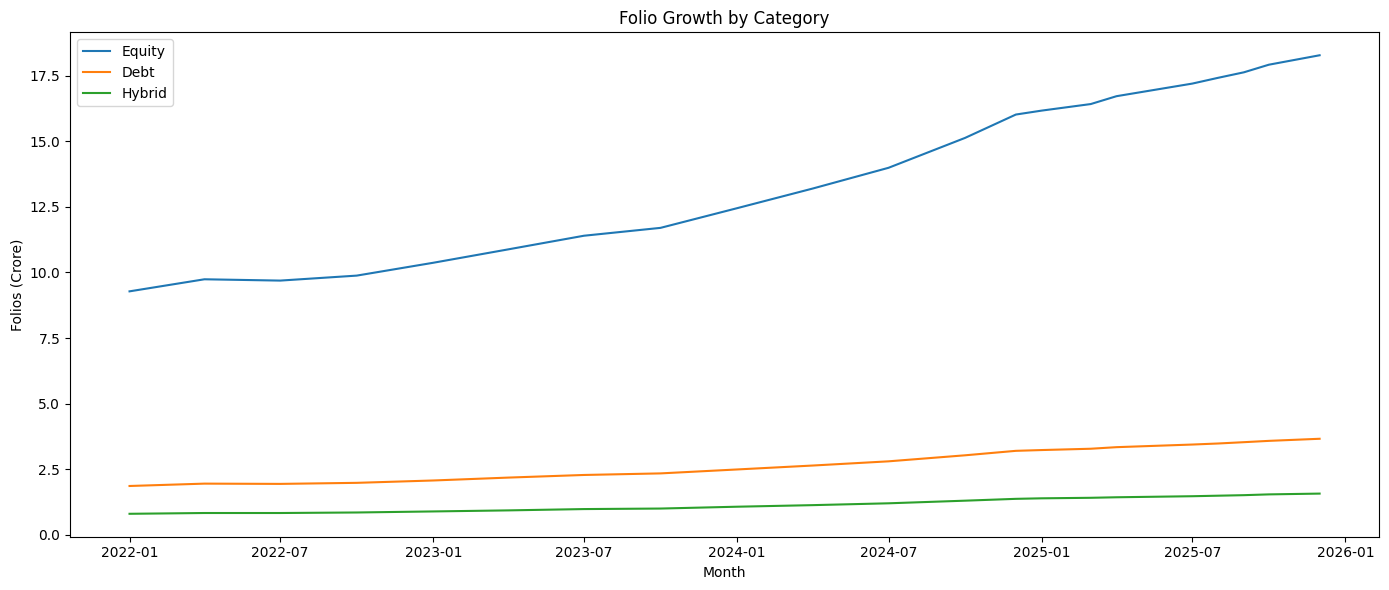

In [29]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["equity_folios_crore"],
    label="Equity"
)

plt.plot(
    folio["month"],
    folio["debt_folios_crore"],
    label="Debt"
)

plt.plot(
    folio["month"],
    folio["hybrid_folios_crore"],
    label="Hybrid"
)

plt.legend()

plt.title("Folio Growth by Category")

plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/folio_category_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### NAV Return Correlation Matrix

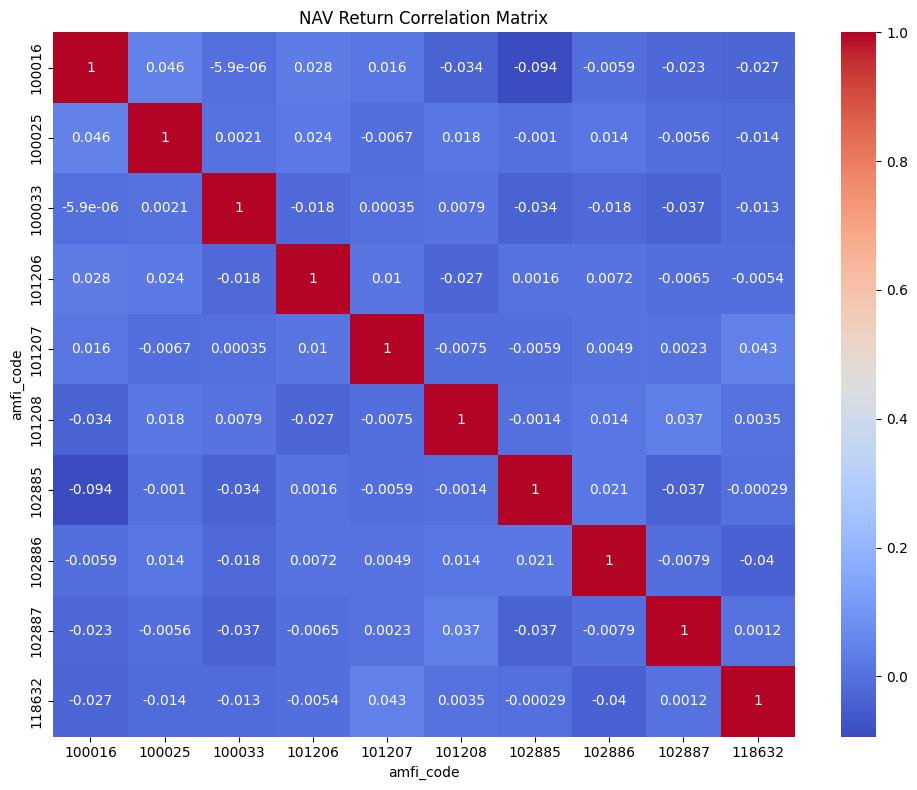

In [30]:
returns_df = nav_history.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns_df = returns_df.pct_change()

top10 = returns_df.columns[:10]

corr_matrix = returns_df[top10].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Insight 10

Most selected mutual fund schemes exhibit positive return correlations, suggesting common exposure to overall market movements.

**Reference:** NAV Return Correlation Matrix

### Sector Allocation Donut Chart

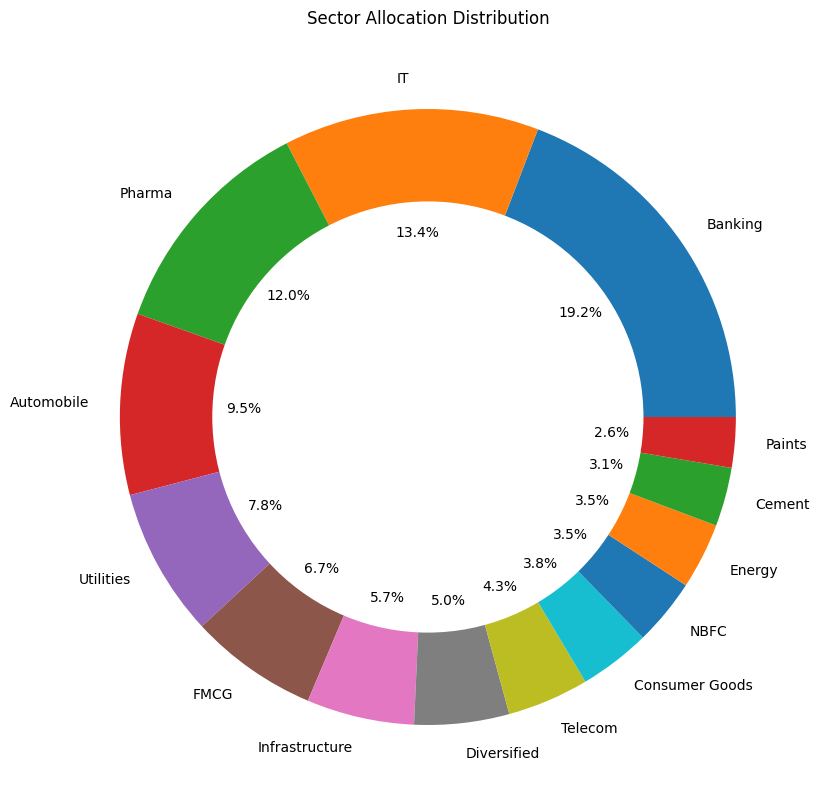

In [31]:
sector_data = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(
    centre_circle
)

plt.title("Sector Allocation Distribution")

plt.savefig(
    "../reports/charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Top 10 Sectors by Portfolio Weight

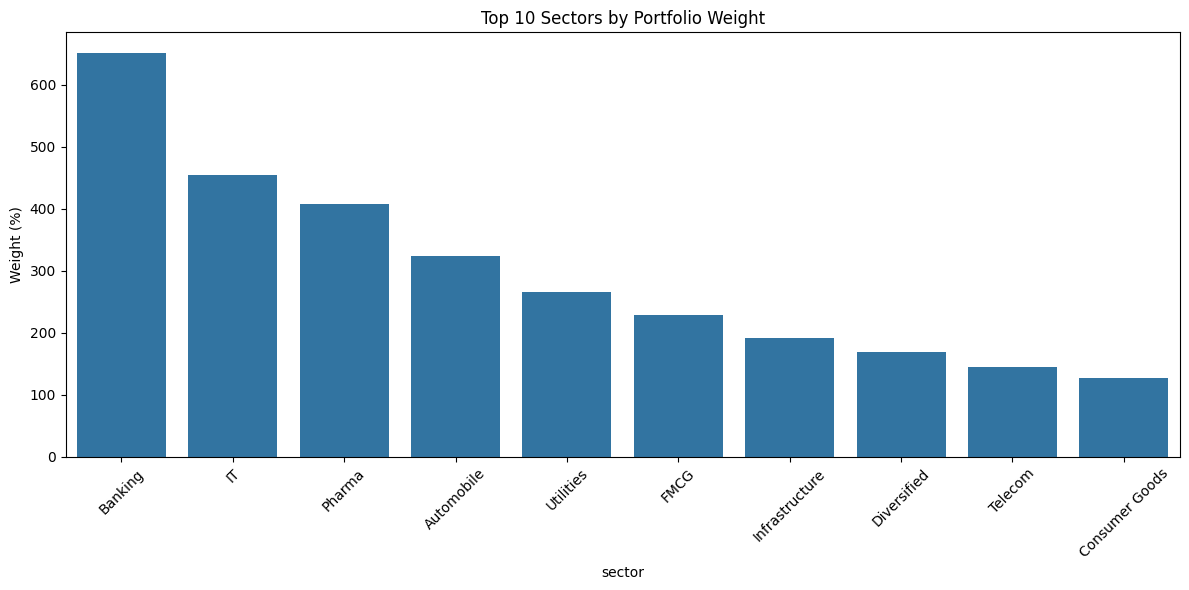

In [32]:
top_sectors = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_sectors.index,
    y=top_sectors.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Sectors by Portfolio Weight")

plt.ylabel("Weight (%)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top10_sectors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Expense Ratio Distribution

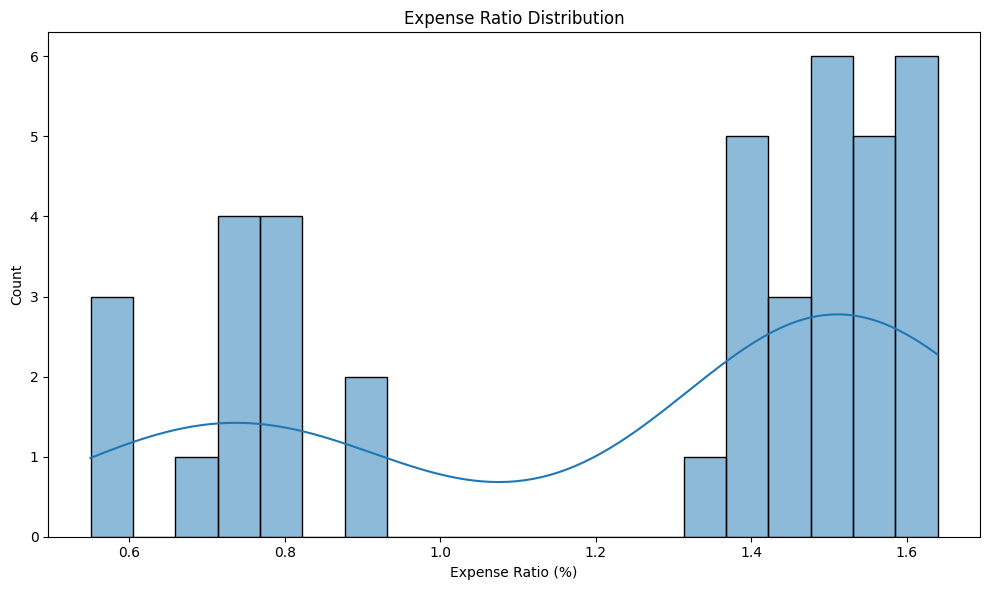

In [33]:
plt.figure(figsize=(10,6))

sns.histplot(
    scheme_perf["expense_ratio_pct"],
    bins=20,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.xlabel("Expense Ratio (%)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Risk Category Distribution

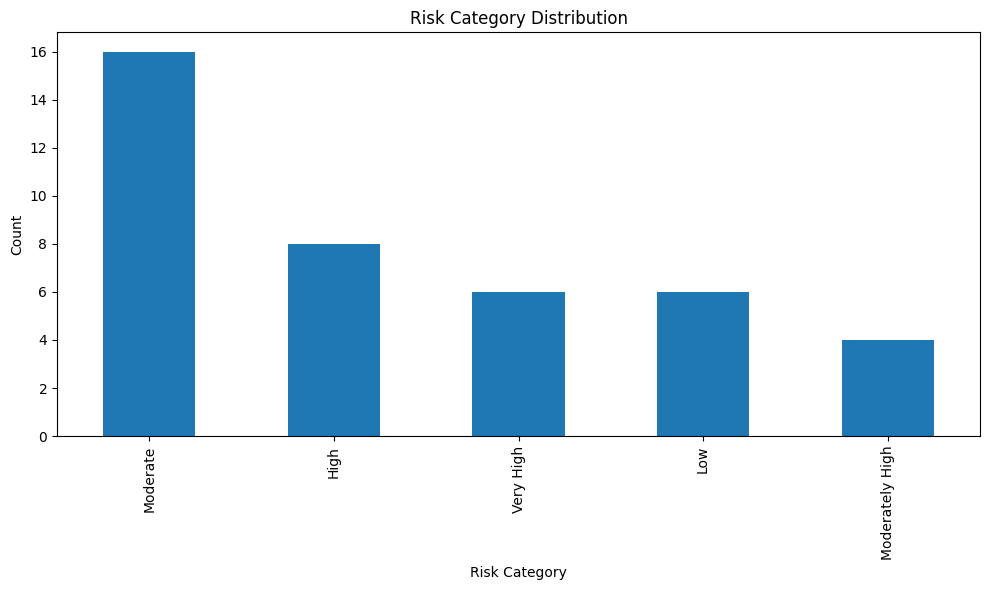

In [34]:
plt.figure(figsize=(10,6))

fund_master["risk_category"].value_counts().plot(
    kind="bar"
)

plt.title("Risk Category Distribution")

plt.xlabel("Risk Category")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../reports/charts/risk_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()